In [14]:
import flux_calc_parallel
import flux_variables
import thermalsyn_v2 as MQ24
import Constants as C
from astropy.cosmology import Planck18

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

from matplotlib.colors import Normalize, LogNorm
from matplotlib.cm import ScalarMappable
from matplotlib import cm
from matplotlib.colors import LinearSegmentedColormap

import pandas as pd

from scipy.optimize import least_squares

In [15]:
# These below params should be altered to see the effects!
s = 1e5 # Effective range of magnetic field values B1/B0
a = 3.0 # Index for magnetic field probability distribution
delta = 1.0 # Index for explicit relation between post-shock number density and magnetic field strength

R = 1e16 # Undocumented... forward shock wave radius
BG = 0.01 # Shock proper velocity at R=R0 (the radius at which the maximum perpendicular 
          # extent of the shock is reached; see Figure 1 in FM25)
n0 = 1e3 # Nominal value for upstream number density
eps_e = 0.1 #eps_e = 0.000001 # Fraction of local fluid energy in power-law electrons
eps_B = 0.1 # Fraction of local fluid energy in magnetic field
eps_T = 0.4 # Fraction of local fluid energy in thermal electrons
p = 3.0 # Power-law electron distribution index
k = 0 # Power-law index for stratified density (Eq. 12 in FM25)
alpha = 0 # Power-law index for deceleration (Eq. 11 in FM25)

# These will flip flop, overlay both when altering the above
therm_el = True # If True---calculates thermal electron synchrotron flux
pl_el = True # If True---calculates power-law electron synchrotron flux

# These stay constant or are already known for a source
T = 50 # Time (days) of observation in observer's frame
mu_u = 0.62 # Mean molecular weight; nominal value 0.62
mu_e = 1.18 # Mean molecular weight per electron; nominal value 1.18
d_L = 10**28 # Luminosity distance (cm)
nu_res = 500 # Frequency array length
z = 0 # Source redshift

#nu_low, nu_high = 1e-2, 1e19 # Full EM range
nu_low, nu_high = 10**(9.5), 1e12

base_params = dict(
a=a, R=R, BG=BG, n0=n0, eps_B=eps_B,
s=s, delta=delta, eps_e=eps_e, eps_T=eps_T, 
p=p, k=k, alpha=alpha, mu_u=mu_u,
mu_e=mu_e, T=T, z=z, d_L=d_L,
nu_res=nu_res, nu_low=nu_low, nu_high=nu_high,
)

# We set mu_u and mu_e to their defaults. 
# Event dependent info: d_L, T

# Things we could change but prob won't:
# eps_e, eps_T, k, alpha, s, delta

# Things we should def change (in accordance to Ross' advice):
# R, BG, n0, a, eps_B

In [16]:
def AT2024wpp(epoch):

    color = "#ffa600"
    name = "24wpp"
    filename = "../../data/whippet_radio.txt"
    data = pd.read_csv(filename, sep="\t", skiprows=1, names=[
           "FBOTName", "dt_days", "nu_GHz", "flux_mJy", "ferr_mJy", "rms_mJy",
           "det", "reference", "obs", "timestart", "timestop", "tmid"])
    Days = data['dt_days'].values # days
    Freq = data['nu_GHz'].values * 1e9 # Hz
    Flux = data['flux_mJy'].values * 1e-3 # Jy 
    eFlux = data['ferr_mJy'].values * 1e-3 # Jy

    #Inclusion of Nayana's ALMA data
    nDays = [18.92, 18.89, 35.76, 35.79]; nFreq = [97.5e9, 203.0e9, 97.5e9, 203.0e9]
    nFlux = [0.000076, 0.000100, 0.001282, 0.000588]; neFlux = [0.000019, 0.000024, 0.000015, 0.000031] # Jy
    Days = np.append(Days, nDays); Freq = np.append(Freq, nFreq)
    Flux = np.append(Flux, nFlux); eFlux = np.append(eFlux, neFlux)

    epochGroups = [
        #[12.02],
        [12.02, 18.92, 18.89], # Added extra ALMA data
        #[28.91,32.9,36.653,33.684,34.714],
        [28.91,32.9,36.653,33.684,34.714,35.76,35.79], # Added extra ALMA data
        [43.88,43.611,43.628,43.670],
        [70.78,71.596,71.614,71.702],
        [110.70, 113.445, 128.65],
        [191.5],
        #[298.25]
    ]

    epochIndex = epoch - 1
    group = np.array(epochGroups[epochIndex])
    tMask = np.any(np.isclose(Days[:, None], group[None, :], rtol=0, atol=1e-3), axis=1)
    freq = Freq[tMask]
    flux = Flux[tMask]
    fluxErr = eFlux[tMask]
    
    # Known info
    T = np.mean(Days[tMask]) # Time (days) of observation in observer's frame
    z = 0.0868 # Source redshift
    d_L = Planck18.luminosity_distance(z).cgs.value # Luminosity distance (cm)

    source_params = {
        **base_params,
        "T": T,
        "z": z,
        "d_L": d_L
    }

    return source_params, freq, flux, fluxErr

In [17]:
# Fitting each epoch's SED with different starting points 
# just to see how varied the bestfits can get

def compute_Lnu_R(freq, params, therm_el, pl_el):
    Lnu = flux_variables.LOS_IHG_Fitted_R(
        freq,
        params["s"], params["a"], params["delta"], params["R"],
        params["T"], params["n0"], params["eps_e"], params["eps_B"], params["eps_T"], params["p"],
        params["mu_u"], params["mu_e"],
        params["BG"], params["k"],
        params["d_L"], params["z"],
        therm_el=therm_el, pl_el=pl_el
    )
    return Lnu

def model_Fnu_at_datafreq(theta, base_params, d_L, freq_hz, therm_el=True, pl_el=True):
    """
    theta = [a, log10R, BG, log10n0, log10eps_B]
    Returns model flux density (Jy) at the data frequencies.
    """
    a, log10R, BG, log10n0, log10epsB = theta

    params = {
        **base_params,
        "a": a,
        "R": 10.0**log10R,
        "BG": BG,
        "n0": 10.0**log10n0,
        "eps_B": 10.0**log10epsB,
    }

    Lnu = compute_Lnu_R(freq_hz, params, therm_el, pl_el)
    Fnu = Lnu / (4*np.pi*d_L**2) / C.Jy  # Jy
    return Fnu

def residuals(theta, base_params, d_L, freq_hz, flux_jy, eflux_jy, therm_el=True, pl_el=True):
    Fnu_model = model_Fnu_at_datafreq(theta, base_params, d_L, freq_hz, therm_el=therm_el, pl_el=pl_el)
    return (Fnu_model - flux_jy) / eflux_jy

def chi2(theta, base_params, d_L, freq_hz, flux_jy, eflux_jy, therm_el=True, pl_el=True):
    r = residuals(theta, base_params, d_L, freq_hz, flux_jy, eflux_jy, therm_el=therm_el, pl_el=pl_el)
    return float(np.sum(r**2))

# a, R, BG, n0, eps_B
lb = np.array([0.5, 14.0, 0.01, -2.0, -5.0]) # lower bounds
ub = np.array([4.0, 18.0, 2.10,  6.0, -0.3]) # upper bounds
bounds = (lb, ub)
theta0 = np.array([3.0,np.log10(1e16),0.01,np.log10(1e3),np.log10(0.1)])

def sample_thetas_uniform(n, lb, ub, seed=None):
    rng = np.random.default_rng(seed)
    u = rng.random((n, len(lb)))
    return lb + u * (ub - lb)

def multistart_fit_epoch(epoch, n_success, bounds, therm_el=True, pl_el=True, max_nfev=1000):
    """
    Collect n_success successful least_squares results or stop at max_attempts.
    """
    lb = np.asarray(bounds[0], float)
    ub = np.asarray(bounds[1], float)

    source_params, freq, flux, fluxErr = AT2024wpp(epoch)
    d_L = source_params['d_L']
    max_attempts = 10 * n_success

    thetas0 = np.full((n_success, len(lb)), np.nan, dtype=float)
    thetas_hat = np.full_like(thetas0, np.nan)
    chi2 = np.full((n_success,), np.nan, dtype=float)
    success = np.zeros((n_success,), dtype=bool)

    got = 0
    attempts = 0
    rng = np.random.default_rng(0) # just chose 0 for seed
    while got < n_success and attempts < max_attempts:
        attempts += 1

        #x0 = sample_thetas_uniform(1, lb, ub, seed=rng.integers(0, 2**32 - 1))[0]  # shape (5,)
        x0 = sample_thetas_uniform(1, lb, ub, seed=None)[0]  # shape (5,)

        try:
            res = least_squares(
                residuals, x0=x0, bounds=(lb, ub),
                args=(source_params, d_L, freq, flux, fluxErr, therm_el, pl_el),
                method="trf", max_nfev=max_nfev
            )

            # Finish run and confirm that there's no nans in the fitting
            if res.success and np.all(np.isfinite(res.x)) and np.isfinite(res.cost):
                thetas0[got] = x0
                thetas_hat[got] = res.x
                chi2[got] = float(np.sum(res.fun**2))
                success[got] = True
                got += 1

                if (got % max(1, n_success // 10) == 0):
                    print(f"Epoch {epoch}: got {got}/{n_success} successes (attempts={attempts})")

        except Exception as e:
            print(f"Epoch {epoch}: attempt {attempts}") # don't crash

    if got < n_success:
        print(f"Warning: epoch {epoch} only got {got}/{n_success} successful fits after {attempts} attempts.")
        # trim arrays to what we actually got
        thetas0 = thetas0[:got]
        thetas_hat = thetas_hat[:got]
        chi2 = chi2[:got]
        success = success[:got]

    ndof = len(freq) - len(lb)
    if ndof > 0: red_chi2 = chi2 / ndof 
    else: red_chi2 = np.full_like(chi2, np.nan)

    return dict(
        epoch=epoch,
        source_params=source_params,
        d_L=d_L,
        freq=freq,
        flux=flux,
        fluxErr=fluxErr,
        theta0s=thetas0,
        thetas=thetas_hat,
        chi2=chi2,
        red_chi2=red_chi2,
        ndof=ndof,
        success=success,
        bounds=(lb, ub),
        therm_el=therm_el,
        pl_el=pl_el,
    )

def select_solutions(out, delta_chi2=10):
    """
    Select 'good' solutions by delta chi-square or by top fraction.
    - delta_chi2: keep solutions with chi2 <= chi2_min + delta_chi2
    """
    chi2 = out["chi2"]
    ok = np.isfinite(chi2)

    ok &= out["success"]

    chi2_min = np.nanmin(chi2[ok])

    ok &= (chi2 <= chi2_min + float(delta_chi2))

    return np.where(ok)[0]
    
def plot_param_hists(out, idx_keep):
    labels = ["a", "log10R", "BG", "log10n0", "log10eps_B"]
    thetas = out["thetas"][idx_keep]
    chi2 = out["chi2"][idx_keep]

    N = len(thetas)
    bins = min(30, max(10, int(np.sqrt(max(N, 1)))))

    fig, axes = plt.subplots(1, thetas.shape[1], figsize=(4*thetas.shape[1], 3))
    if thetas.shape[1] == 1:
        axes = [axes]

    for j in range(thetas.shape[1]):
        axes[j].hist(thetas[:, j], bins=bins)
        axes[j].set_xlabel(labels[j])
        axes[j].set_ylabel("count")

    fig.suptitle(
        f"Epoch {out['epoch']} | kept {len(idx_keep)} sols | "
        f"chi2_min={np.nanmin(chi2):.2g} (ndof={out['ndof']})",
        y=1.05
    )
    fig.tight_layout()
    return fig, axes

def theta_to_physical(theta):
    """Map [a, log10R, BG, log10n0, log10epsB] -> physical values."""
    a, log10R, BG, log10n0, log10epsB = theta
    return dict(
        a=float(a),
        R=10.0**float(log10R),
        BG=float(BG),
        n0=10.0**float(log10n0),
        eps_B=10.0**float(log10epsB),
    )

def plot_overlay_curves(out, idx_keep):
    source_params = out["source_params"]
    d_L = out["d_L"]
    freq, flux, fluxErr = out["freq"], out["flux"], out["fluxErr"]
    therm_el, pl_el = out["therm_el"], out["pl_el"]

    nu_grid = np.logspace(np.log10(nu_low), np.log10(nu_high), int(nu_res))

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.errorbar(freq, flux, yerr=fluxErr, fmt="o", label="Data")

    for i in idx_keep:
        theta = out["thetas"][i]
        phys = theta_to_physical(theta)
        params = {**source_params, **phys}

        Lnu = compute_Lnu_R(nu_grid, params, therm_el, pl_el)
        Fnu = Lnu / (4*np.pi*d_L**2) / C.Jy
        ax.plot(nu_grid, Fnu, lw=1, alpha=0.3)

    # best curve thick
    chi2 = out["chi2"]
    best_i = idx_keep[np.argmin(chi2[idx_keep])]
    best_theta = out["thetas"][best_i]
    best_phys = theta_to_physical(best_theta)
    params_best = {**source_params, **best_phys}
    
    Lnu_best = compute_Lnu_R(nu_grid, params_best, therm_el, pl_el)
    Fnu_best = Lnu_best / (4*np.pi*d_L**2) / C.Jy
    ax.plot(nu_grid, Fnu_best, lw=3, label="Best (min chi2)")

    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel(r"$\nu$ (Hz)"); ax.set_ylabel(r"$F_\nu$ (Jy)")
    ax.set_title(f"Epoch {out['epoch']} | overlay {len(idx_keep)} solutions")
    ax.legend(); fig.tight_layout()
    return fig, ax

def summarize_solutions(out, idx_keep):
    if len(idx_keep) == 0: print("No solutions selected."); return

    chi2 = out["chi2"][idx_keep]
    thetas = out["thetas"][idx_keep]
    best = idx_keep[np.argmin(chi2)]
    print(f"Selected {len(idx_keep)} solutions")
    print(f"chi2 min/med/max = {np.min(chi2):.3g} / {np.median(chi2):.3g} / {np.max(chi2):.3g}")
    print("Best theta:", out["thetas"][best])
    print("Best physical:", theta_to_physical(out["thetas"][best]))



=== Epoch 1 ===
Epoch 1: got 100/1000 successes (attempts=100)
Epoch 1: got 200/1000 successes (attempts=200)
Epoch 1: got 300/1000 successes (attempts=300)
Epoch 1: got 400/1000 successes (attempts=400)
Epoch 1: got 500/1000 successes (attempts=500)
Epoch 1: got 600/1000 successes (attempts=600)
Epoch 1: got 700/1000 successes (attempts=700)
Epoch 1: got 800/1000 successes (attempts=800)
Epoch 1: got 900/1000 successes (attempts=900)
Epoch 1: got 1000/1000 successes (attempts=1000)
Selected 949 solutions
chi2 min/med/max = 4.37e-25 / 1.93e-15 / 0.219
Best theta: [ 2.70308118 15.48900764  1.63104617  2.25642719 -0.47431744]
Best physical: {'a': 2.703081181543045, 'R': 3083242161394900.5, 'BG': 1.6310461745766396, 'n0': 180.47921430367478, 'eps_B': 0.3354923012415422}


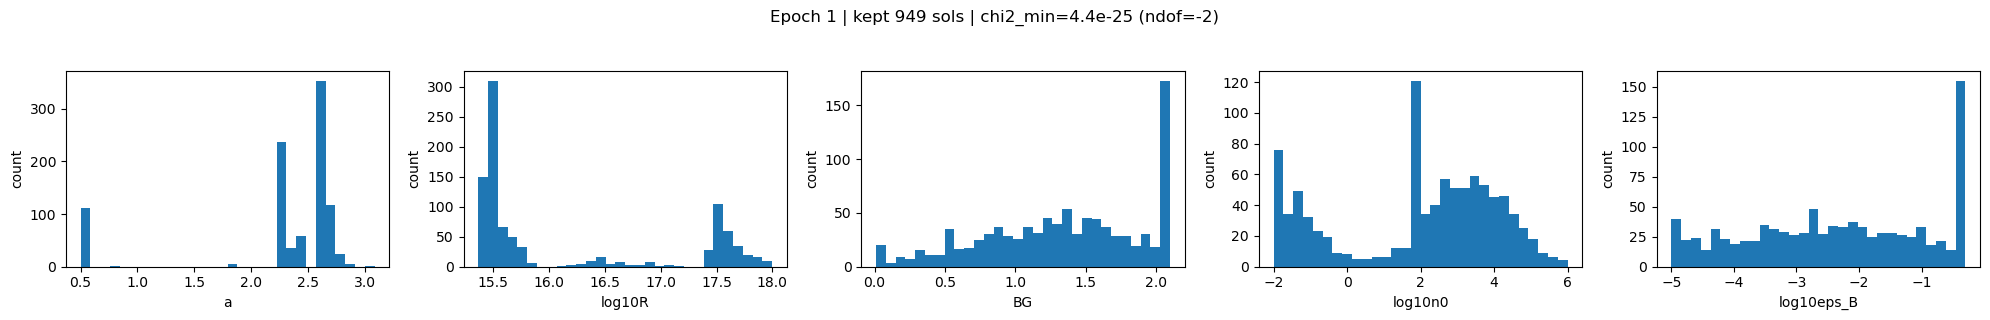

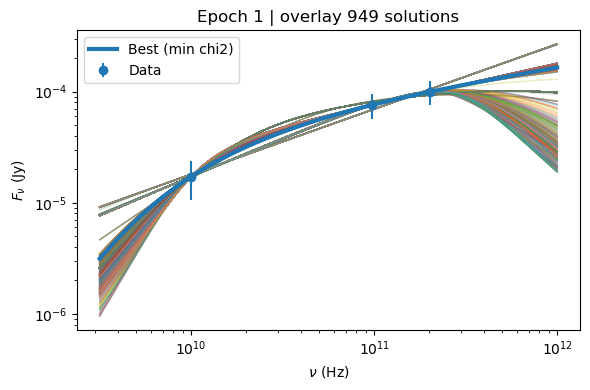

Epoch 1: kept 949 solutions

=== Epoch 2 ===
Epoch 2: got 100/1000 successes (attempts=100)
Epoch 2: got 200/1000 successes (attempts=200)
Epoch 2: got 300/1000 successes (attempts=300)
Epoch 2: got 400/1000 successes (attempts=400)
Epoch 2: got 500/1000 successes (attempts=500)
Epoch 2: got 600/1000 successes (attempts=600)
Epoch 2: got 700/1000 successes (attempts=700)
Epoch 2: got 800/1000 successes (attempts=800)
Epoch 2: got 900/1000 successes (attempts=900)
Epoch 2: got 1000/1000 successes (attempts=1000)
Selected 267 solutions
chi2 min/med/max = 62.5 / 62.5 / 62.6
Best theta: [ 1.81092868 17.84304506  0.5664719  -1.35307056 -0.3       ]
Best physical: {'a': 1.8109286800505822, 'R': 6.966987890805633e+17, 'BG': 0.5664719005285903, 'n0': 0.04435365759639206, 'eps_B': 0.5011872335996601}


<Figure size 640x480 with 0 Axes>

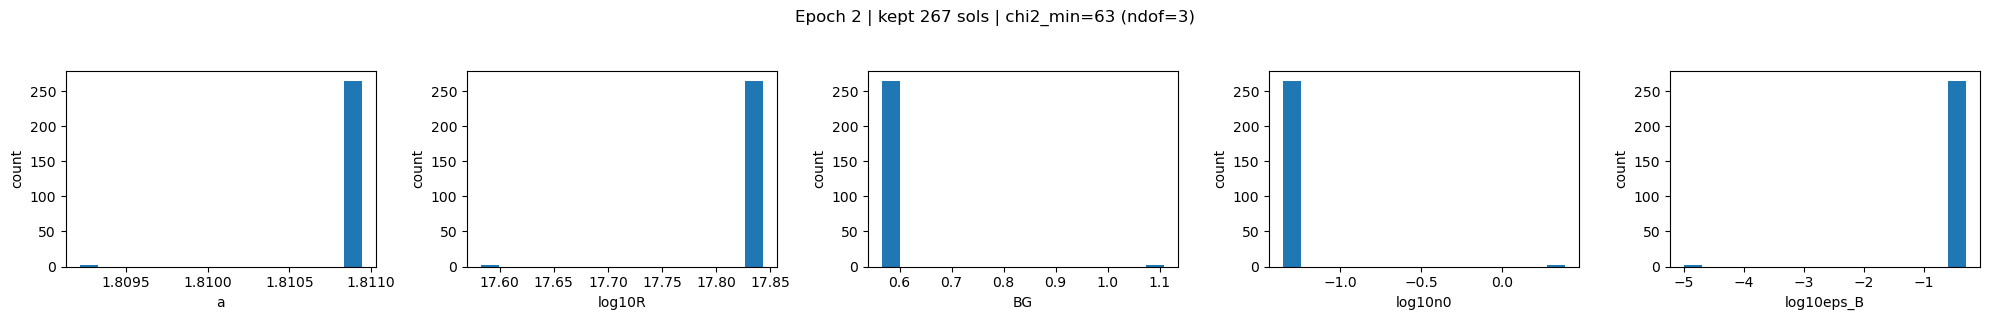

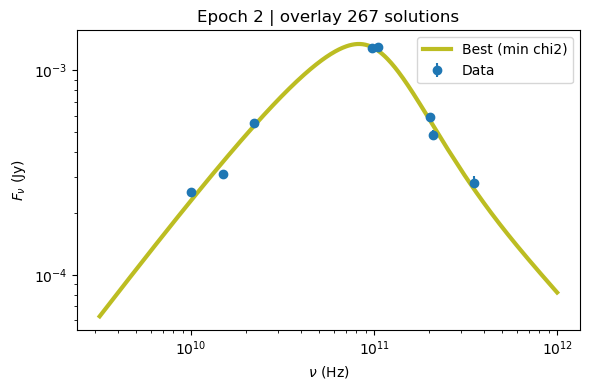

Epoch 2: kept 267 solutions

=== Epoch 3 ===
Epoch 3: got 100/1000 successes (attempts=100)
Epoch 3: got 200/1000 successes (attempts=200)
Epoch 3: got 300/1000 successes (attempts=300)
Epoch 3: got 400/1000 successes (attempts=400)
Epoch 3: got 500/1000 successes (attempts=500)
Epoch 3: got 600/1000 successes (attempts=600)
Epoch 3: got 700/1000 successes (attempts=700)
Epoch 3: got 800/1000 successes (attempts=800)
Epoch 3: got 900/1000 successes (attempts=900)
Epoch 3: got 1000/1000 successes (attempts=1000)
Selected 224 solutions
chi2 min/med/max = 27.7 / 27.7 / 27.8
Best theta: [ 0.86694239 16.53174595  1.0346746   0.77939173 -0.30000007]
Best physical: {'a': 0.8669423874919686, 'R': 3.402091164648592e+16, 'BG': 1.034674599908842, 'n0': 6.017162363538563, 'eps_B': 0.501187155150997}


<Figure size 640x480 with 0 Axes>

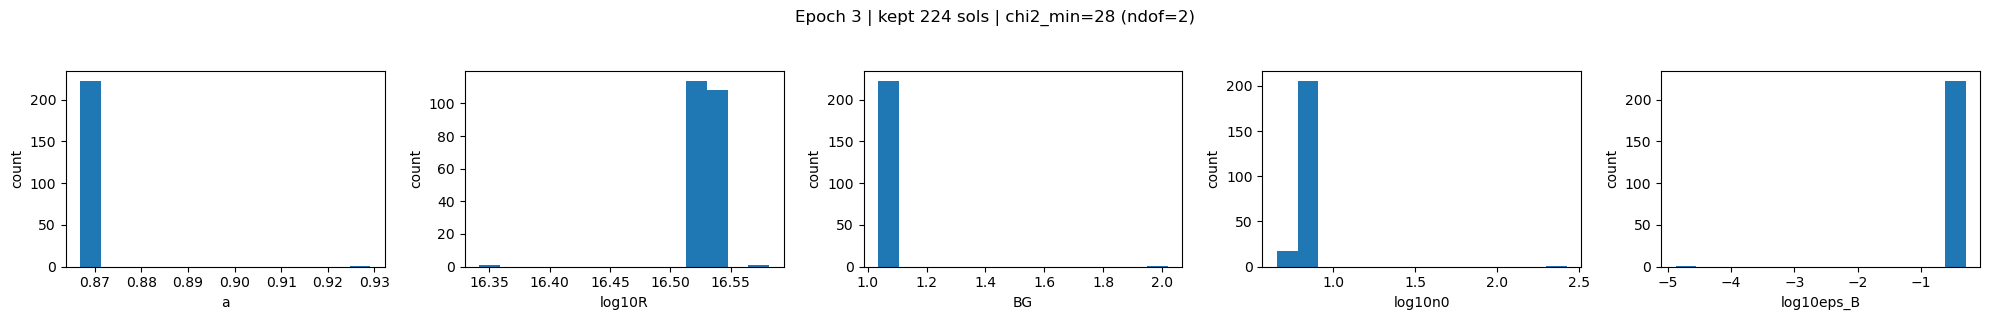

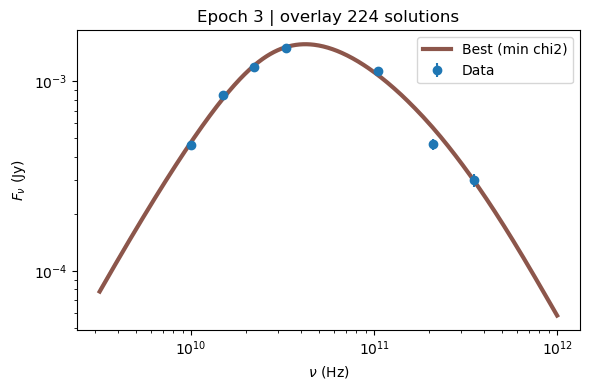

Epoch 3: kept 224 solutions

=== Epoch 4 ===
Epoch 4: got 100/1000 successes (attempts=124)
Epoch 4: got 200/1000 successes (attempts=241)
Epoch 4: got 300/1000 successes (attempts=373)
Epoch 4: got 400/1000 successes (attempts=489)
Epoch 4: got 500/1000 successes (attempts=606)
Epoch 4: got 600/1000 successes (attempts=739)
Epoch 4: got 700/1000 successes (attempts=869)
Epoch 4: got 800/1000 successes (attempts=1003)
Epoch 4: got 900/1000 successes (attempts=1132)
Epoch 4: got 1000/1000 successes (attempts=1255)
Selected 577 solutions
chi2 min/med/max = 12.7 / 12.7 / 12.7
Best theta: [ 4.         16.65070164  0.54812346  1.63978821 -0.30000072]
Best physical: {'a': 3.9999999999999996, 'R': 4.47405835896823e+16, 'BG': 0.5481234572998706, 'n0': 43.630301388041836, 'eps_B': 0.5011863993279928}


<Figure size 640x480 with 0 Axes>

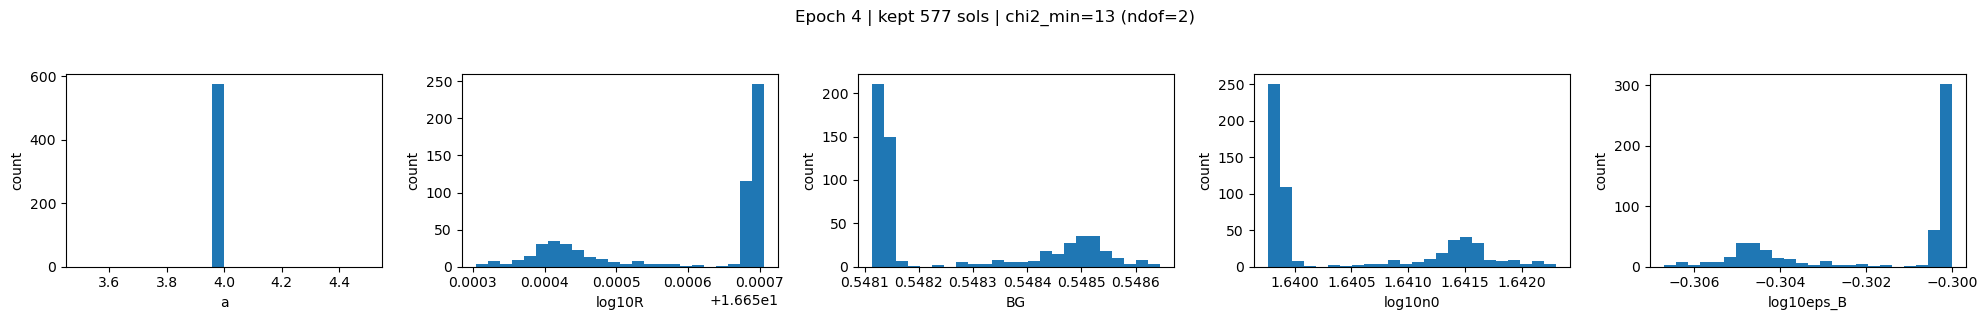

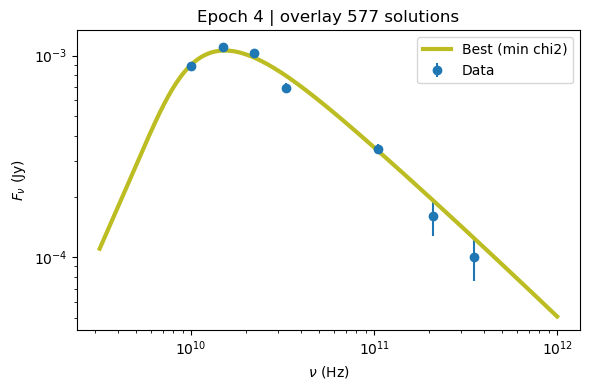

Epoch 4: kept 577 solutions

=== Epoch 5 ===
Epoch 5: got 100/1000 successes (attempts=100)
Epoch 5: got 200/1000 successes (attempts=200)
Epoch 5: got 300/1000 successes (attempts=300)
Epoch 5: got 400/1000 successes (attempts=400)
Epoch 5: got 500/1000 successes (attempts=500)
Epoch 5: got 600/1000 successes (attempts=600)
Epoch 5: got 700/1000 successes (attempts=700)
Epoch 5: got 800/1000 successes (attempts=800)
Epoch 5: got 900/1000 successes (attempts=900)
Epoch 5: got 1000/1000 successes (attempts=1000)
Selected 952 solutions
chi2 min/med/max = 0.91 / 2.97 / 4.71
Best theta: [ 0.55642238 16.98824992  0.31300943  1.70495675 -0.31931948]
Best physical: {'a': 0.5564223766164599, 'R': 9.733071531493075e+16, 'BG': 0.3130094284930323, 'n0': 50.69402170380648, 'eps_B': 0.47938067482150787}


<Figure size 640x480 with 0 Axes>

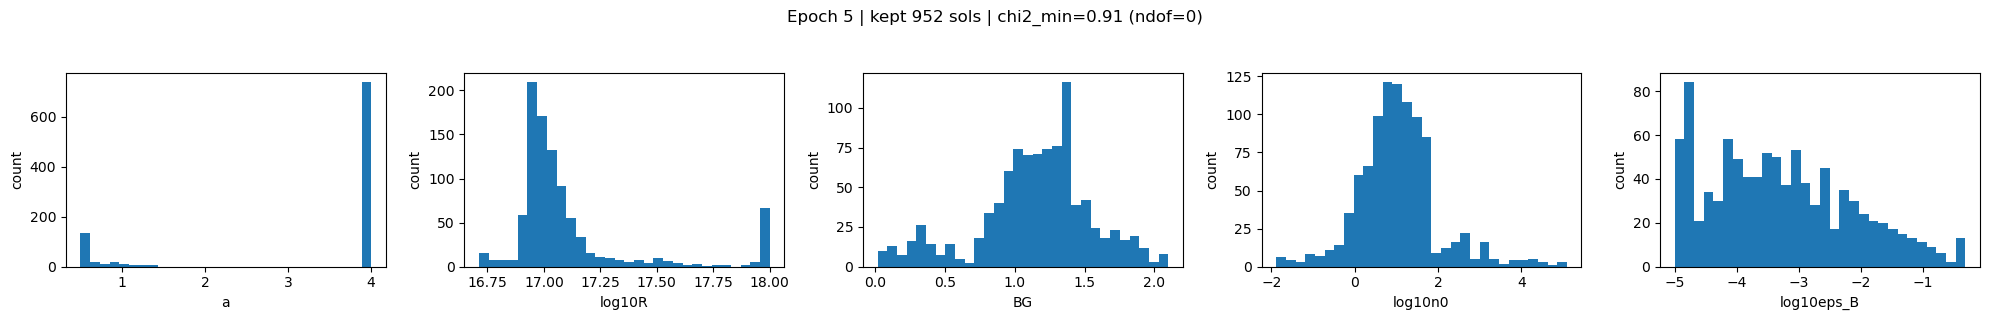

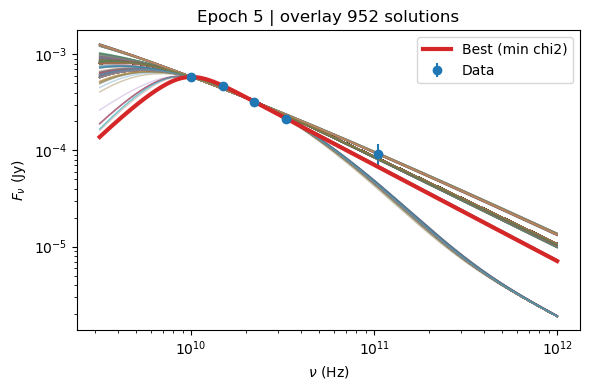

Epoch 5: kept 952 solutions

=== Epoch 6 ===


In [ ]:
epochs = [1, 2, 3, 4, 5, 6]

outs = {}
keeps = {}

lb = np.array([0.5, 14.0, 0.01, -2.0, -5.0])
ub = np.array([4.0, 18.0, 2.10,  6.0, -0.3])
bounds = (lb, ub)

for ep in epochs:
    print(f"\n=== Epoch {ep} ===")

    outs[ep] = multistart_fit_epoch(
        epoch=ep,
        n_success=1000,
        bounds=bounds,
        therm_el=True,
        pl_el=True,
        max_nfev=5000
    )

    idx_keep = select_solutions(outs[ep], delta_chi2=10.0)
    summarize_solutions(outs[ep], idx_keep)

    plot_param_hists(outs[ep], idx_keep)
    plot_overlay_curves(outs[ep], idx_keep)
    plt.show(); plt.clf()

    keeps[ep] = select_solutions(outs[ep], delta_chi2=10.0)

    print(f"Epoch {ep}: kept {len(keeps[ep])} solutions")

In [23]:
def weighted_quantile(x, q, w):
    """
    x: (N,) values
    q: quantile in [0,1] or array of quantiles
    w: (N,) nonnegative weights
    """
    x = np.asarray(x)
    w = np.asarray(w)
    q = np.atleast_1d(q)

    s = np.argsort(x)
    x = x[s]
    w = w[s]

    cdf = np.cumsum(w)
    cdf = cdf / cdf[-1]

    return np.interp(q, cdf, x)

def plot_param_evolution(outs, keeps, epochs, show_err=False, min_keep=10, weighted=True):
    t = np.array([outs[ep]["source_params"]["T"] for ep in epochs], float)

    best_theta = np.full((len(epochs), 5), np.nan, float)
    q16 = np.full_like(best_theta, np.nan)
    q50 = np.full_like(best_theta, np.nan)
    q84 = np.full_like(best_theta, np.nan)
    has_err = np.zeros(len(epochs), dtype=bool)

    for k, ep in enumerate(epochs):
        out = outs[ep]
        idx = keeps[ep]

        chi2k = out["chi2"][idx]
        thetas = out["thetas"][idx]

        best_i = idx[np.argmin(chi2k)]
        best_theta[k] = out["thetas"][best_i]

        if show_err and (len(idx) >= min_keep):
            if weighted:
                chi2_min = np.min(chi2k)
                w = np.exp(-0.5*(chi2k - chi2_min))
                for j in range(5):
                    q16[k, j], q50[k, j], q84[k, j] = weighted_quantile(
                        thetas[:, j], [0.16, 0.50, 0.84], w
                    )
            else:
                q16[k], q50[k], q84[k] = np.percentile(thetas, [16, 50, 84], axis=0)

            has_err[k] = True

    fig, axes = plt.subplots(5, 1, figsize=(7, 12), sharex=True)

    for j in range(5):
        # Always overlay best-fit as x
        axes[j].plot(t, best_theta[:, j], "x-", alpha=0.6, label="best-fit")

        # Error summary (median + interval) as primary marker
        if show_err and np.any(has_err):
            tt = t[has_err]
            yy = q50[has_err, j]
            yerr = np.vstack([yy - q16[has_err, j], q84[has_err, j] - yy])
            axes[j].errorbar(tt, yy, yerr=yerr, fmt="o", capsize=3,
                             label=("w-median ± (16,84)%" if weighted else "median ± (16,84)%"))

        axes[j].set_ylabel(labels[j])
        axes[j].legend(loc="best")

    axes[-1].set_xlabel("T (days)")
    fig.tight_layout()
    plt.show()

    return best_theta, (q16, q50, q84), has_err

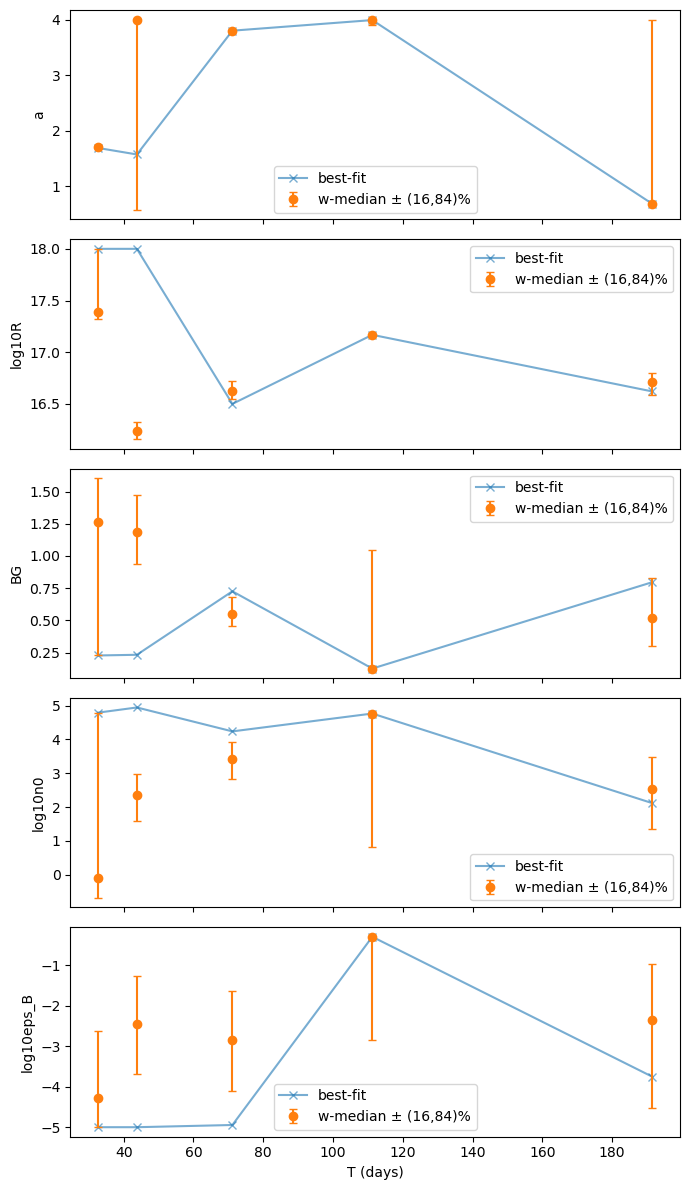

(array([[ 1.68783722, 18.        ,  0.22837261,  4.7894201 , -5.        ],
        [ 1.57077412, 18.        ,  0.23365789,  4.9425684 , -5.        ],
        [ 3.79910506, 16.49910551,  0.72603291,  4.23613361, -4.94553492],
        [ 3.99003416, 17.16785313,  0.1267685 ,  4.76328259, -0.30002871],
        [ 0.68155149, 16.61986407,  0.79672183,  2.11649376, -3.75380305]]),
 (array([[ 1.68783722, 17.32526393,  0.22837261, -0.68186529, -5.        ],
         [ 0.57219841, 16.15715809,  0.93891401,  1.58012595, -3.69356572],
         [ 3.79910488, 16.547156  ,  0.45530361,  2.83891024, -4.10410244],
         [ 3.90639987, 17.16769417,  0.12678165,  0.80857889, -2.84265629],
         [ 0.68155147, 16.58702481,  0.30044671,  1.34738175, -4.51627266]]),
  array([[ 1.70880706, 17.39298386,  1.26538884, -0.0805227 , -4.27917957],
         [ 4.        , 16.23740143,  1.18407515,  2.35122146, -2.44603769],
         [ 3.79910545, 16.62618056,  0.55067269,  3.4153833 , -2.83629348],
         [ 3.

In [25]:
epochs = [1,2,3,4,5]
labels = ["a", "log10R", "BG", "log10n0", "log10eps_B"]
#plot_param_evolution(outs, keeps, epochs, show_err=False)
plot_param_evolution(outs, keeps, epochs, show_err=True, min_keep=5)

In [9]:
# Let's grab epoch 2's bestfit eps_B and fix it for other epochs
ep1 = 2 # epoch 2
idx_keep1 = select_solutions(outs[ep1], delta_chi2=10.0)
best_i1 = idx_keep1[np.argmin(outs[ep1]["chi2"][idx_keep1])]
best_theta1 = outs[ep1]["thetas"][best_i1] # [a, log10R, BG, log10n0, log10epsB]
idx_keep = select_solutions(outs[ep1], delta_chi2=10.0)
log10epsB_fixed = float(best_theta1[4])
epsB_fixed = 10**log10epsB_fixed

print("Freezing eps_B to epoch-1 best-fit:")
print("log10eps_B = ", log10epsB_fixed)
print("eps_B = ", epsB_fixed)

# NEARLY IDENTICAL CODE FOR FOUR FREE PARAMETERS
def theta4_to_physical(theta4, log10epsB_fixed):
    a, log10R, BG, log10n0 = theta4
    return dict(
        a=float(a),
        R=10.0**float(log10R),
        BG=float(BG),
        n0=10.0**float(log10n0),
        eps_B=10.0**float(log10epsB_fixed),
    )

def residuals_4(theta4, base_params, d_L, freq_hz, flux_jy, eflux_jy,
                therm_el=True, pl_el=False, log10epsB_fixed=-1.0):
    phys = theta4_to_physical(theta4, log10epsB_fixed)
    params = {**base_params, **phys}

    Lnu = flux_variables.LOS_IHG_Fitted_R(
        freq_hz,
        params["s"], params["a"], params["delta"], params["R"],
        params["T"], params["n0"], params["eps_e"], params["eps_B"], params["eps_T"], params["p"],
        params["mu_u"], params["mu_e"],
        params["BG"], params["k"],
        params["d_L"], params["z"],
        therm_el=therm_el, pl_el=pl_el
    )
    Fnu = Lnu / (4*np.pi*d_L**2) / C.Jy
    return (Fnu - flux_jy) / eflux_jy

lb4 = np.array([0.5, 14.0, 0.01, -2.0])  # a, log10R, BG, log10n0
ub4 = np.array([4.0, 18.0, 2.10,  6.0])
bounds4 = (lb4, ub4)

def multistart_fit_epoch_4(epoch, n_success, bounds4, log10epsB_fixed, therm_el=True, 
                           pl_el=False, max_nfev=2000):
    
    lb, ub = np.asarray(bounds4[0], float), np.asarray(bounds4[1], float)
    source_params, freq, flux, fluxErr = AT2024wpp(epoch)
    d_L = source_params['d_L']
    max_attempts = 10 * n_success

    thetas0 = np.full((n_success, len(lb)), np.nan, float)
    thetas_hat = np.full_like(thetas0, np.nan)
    chi2 = np.full((n_success,), np.nan, float)
    success = np.zeros((n_success,), dtype=bool)

    rng = np.random.default_rng(None)
    got = 0
    attempts = 0

    while got < n_success and attempts < max_attempts:
        attempts += 1
        x0 = (lb + rng.random(len(lb)) * (ub - lb))  # shape (4,)

        try:
            res = least_squares(
                residuals_4,
                x0=x0,
                bounds=(lb, ub),
                args=(source_params, d_L, freq, flux, fluxErr, therm_el, pl_el, log10epsB_fixed),
                method="trf",
                max_nfev=max_nfev,
            )
            if res.success:
                thetas0[got] = x0
                thetas_hat[got] = res.x
                chi2[got] = float(np.sum(res.fun**2))
                success[got] = True
                got += 1

                if verbose and got % max(1, n_success // 10) == 0:
                    print(f"Epoch {epoch}: got {got}/{n_success} successes (attempts={attempts})")

        except Exception:
            pass

    if got < n_success:
        print(f"Warning: epoch {epoch} only got {got}/{n_success} successes after {attempts} attempts.")
        thetas0 = thetas0[:got]
        thetas_hat = thetas_hat[:got]
        chi2 = chi2[:got]
        success = success[:got]

    ndof = len(freq) - len(lb)
    red_chi2 = chi2 / ndof if ndof > 0 else np.full_like(chi2, np.nan)

    return dict(
        epoch=epoch,
        source_params=source_params,
        d_L=d_L,
        freq=freq,
        flux=flux,
        fluxErr=fluxErr,
        theta0s=thetas0,
        thetas=thetas_hat,
        chi2=chi2,
        red_chi2=red_chi2,
        ndof=ndof,
        success=success,
        bounds=(lb, ub),
        log10epsB_fixed=float(log10epsB_fixed),
        therm_el=therm_el,
        pl_el=pl_el,
    )

def plot_overlay_curves_4(out, idx_keep, nu_low=None, nu_high=None, nu_res=None):
    sp = out["source_params"]
    d_L = out["d_L"]
    therm_el, pl_el = out["therm_el"], out["pl_el"]
    log10epsB_fixed = out["log10epsB_fixed"]

    nu_grid = np.logspace(np.log10(nu_low), np.log10(nu_high), int(nu_res))

    fig, ax = plt.subplots(figsize=(6,4))
    ax.errorbar(out["freq"], out["flux"], yerr=out["fluxErr"], fmt="o", label="Data")

    for i in idx_keep:
        theta4 = out["thetas"][i]
        phys = theta4_to_physical(theta4, log10epsB_fixed)
        params = {**sp, **phys}

        Lnu = compute_Lnu_R(nu_grid, params, therm_el, pl_el)
        Fnu = Lnu / (4*np.pi*d_L**2) / C.Jy
        ax.plot(nu_grid, Fnu, lw=1, alpha=0.3)

    # best thick
    chi2 = out["chi2"][idx_keep]
    best_i = idx_keep[np.argmin(chi2)]
    best_theta4 = out["thetas"][best_i]
    best_phys = theta4_to_physical(best_theta4, log10epsB_fixed)
    params_best = {**sp, **best_phys}

    Lnu_best = compute_Lnu_R(nu_grid, params_best, therm_el, pl_el)
    Fnu_best = Lnu_best / (4*np.pi*d_L**2) / C.Jy
    ax.plot(nu_grid, Fnu_best, lw=3, label="Best (min chi2)")

    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel(r"$\nu$ (Hz)"); ax.set_ylabel(r"$F_\nu$ (Jy)")
    ax.set_title(f"Epoch {out['epoch']} | eps_B fixed = {10**log10epsB_fixed:.3g}")
    ax.legend()
    fig.tight_layout()
    return fig, ax

def plot_param_evolution_4(outs4, keeps4, epochs):
    labels4 = ["a", "log10R", "BG", "log10n0"]
    t = np.array([outs4[ep]["source_params"]["T"] for ep in epochs], float)

    best = np.full((len(epochs), 4), np.nan, float)

    for k, ep in enumerate(epochs):
        out = outs4[ep]
        idx = keeps4[ep]
        chi2 = out["chi2"][idx]
        best_i = idx[np.argmin(chi2)]
        best[k] = out["thetas"][best_i]

    fig, axes = plt.subplots(4, 1, figsize=(7, 8), sharex=True)
    for j in range(4):
        axes[j].plot(t, best[:, j], "x-")
        axes[j].set_ylabel(labels4[j])

    axes[-1].set_xlabel("T (days)")
    fig.tight_layout()
    plt.show()
    return best

def print_best_fit_4(out, idx_keep=None):
    chi2 = out["chi2"]
    if idx_keep is None or len(idx_keep) == 0:
        best_i = int(np.nanargmin(chi2))
    else:
        best_i = int(idx_keep[np.argmin(chi2[idx_keep])])

    theta4 = out["thetas"][best_i]  # [a, log10R, BG, log10n0]
    phys = theta4_to_physical(theta4, out["log10epsB_fixed"])

    print(f"\nEpoch {out['epoch']} best-fit (eps_B fixed):")
    print("theta4 = [a, log10R, BG, log10n0] =", theta4)
    print(f"chi2 = {chi2[best_i]:.4g} | red_chi2 = {out['red_chi2'][best_i]:.4g} | ndof = {out['ndof']}")
    print("physical:", phys)  # includes eps_B
    return best_i, theta4, phys

Freezing eps_B to epoch-1 best-fit:
log10eps_B =  -4.999999999999996
eps_B =  1.0000000000000102e-05



Epoch 1 best-fit (eps_B fixed):
theta4 = [a, log10R, BG, log10n0] = [ 1.68783722 18.          0.22837261  4.7894201 ]
chi2 = 3.659 | red_chi2 = 1.829 | ndof = 2
physical: {'a': 1.6878372232778738, 'R': 9.999999999999918e+17, 'BG': 0.22837260689610525, 'n0': 61577.22328880649, 'eps_B': 1.0000000000000102e-05}


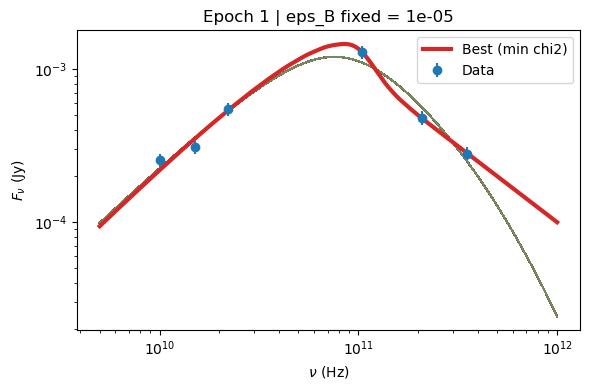


Epoch 2 best-fit (eps_B fixed):
theta4 = [a, log10R, BG, log10n0] = [ 1.57077396 18.          0.23365779  4.94256928]
chi2 = 3.459 | red_chi2 = 1.153 | ndof = 3
physical: {'a': 1.5707739578769777, 'R': 9.999999999999918e+17, 'BG': 0.2336577921519916, 'n0': 87613.14723657568, 'eps_B': 1.0000000000000102e-05}


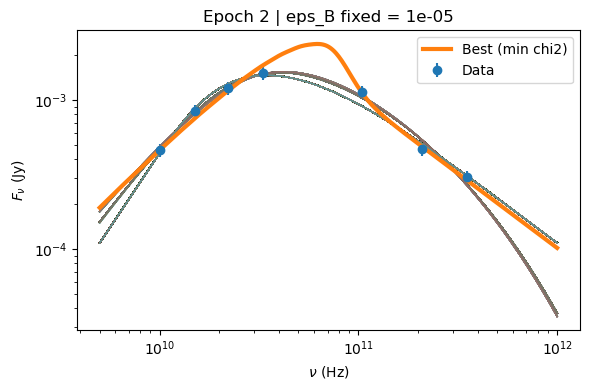


Epoch 3 best-fit (eps_B fixed):
theta4 = [a, log10R, BG, log10n0] = [ 3.799105   16.49604724  0.7316454   4.25642412]
chi2 = 2.914 | red_chi2 = 0.9714 | ndof = 3
physical: {'a': 3.7991050026534046, 'R': 3.1336265849658628e+16, 'BG': 0.7316453977277967, 'n0': 18047.793908340107, 'eps_B': 1.0000000000000102e-05}


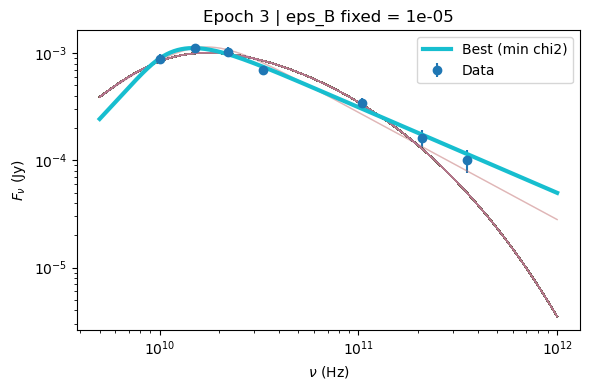


Epoch 4 best-fit (eps_B fixed):
theta4 = [a, log10R, BG, log10n0] = [ 3.93943728 16.81231685  0.32246058  6.        ]
chi2 = 0.7154 | red_chi2 = 0.7154 | ndof = 1
physical: {'a': 3.939437280773226, 'R': 6.491078313161271e+16, 'BG': 0.322460577759257, 'n0': 999999.9999998998, 'eps_B': 1.0000000000000102e-05}


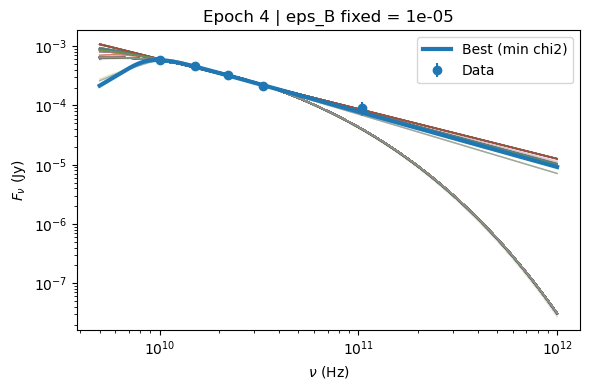


Epoch 5 best-fit (eps_B fixed):
theta4 = [a, log10R, BG, log10n0] = [ 0.6815515  16.55342749  0.95108544  2.57636846]
chi2 = 4.419e-29 | red_chi2 = nan | ndof = 0
physical: {'a': 0.6815515028591087, 'R': 3.5762468819748068e+16, 'BG': 0.9510854429815865, 'n0': 377.0235299292041, 'eps_B': 1.0000000000000102e-05}


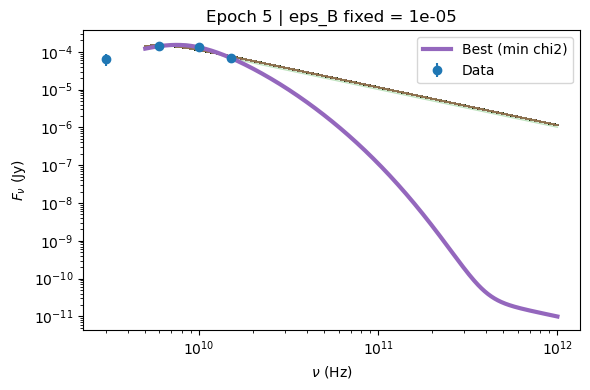


Summary best-fit physical params by epoch:
1 1.6878372232778738 9.999999999999918e+17 0.22837260689610525 61577.22328880649 1.0000000000000102e-05
2 1.5707739578769777 9.999999999999918e+17 0.2336577921519916 87613.14723657568 1.0000000000000102e-05
3 3.7991050026534046 3.1336265849658628e+16 0.7316453977277967 18047.793908340107 1.0000000000000102e-05
4 3.939437280773226 6.491078313161271e+16 0.322460577759257 999999.9999998998 1.0000000000000102e-05
5 0.6815515028591087 3.5762468819748068e+16 0.9510854429815865 377.0235299292041 1.0000000000000102e-05


In [10]:
epochs = [1,2,3,4,5,6]

outs4 = {}
keeps4 = {}

best_phys_by_epoch = {}
best_theta_by_epoch = {}

for ep in epochs:
    outs4[ep] = multistart_fit_epoch_4(
        epoch=ep,
        n_success=1000,
        bounds4=bounds4,
        log10epsB_fixed=log10epsB_fixed,
        therm_el=True, pl_el=True,
        max_nfev=5000
    )

    keeps4[ep] = select_solutions(outs4[ep], delta_chi2=10.0)

    best_i, theta4, phys = print_best_fit_4(outs4[ep], keeps4[ep])
    best_phys_by_epoch[ep] = phys
    best_theta_by_epoch[ep] = theta4

    plot_overlay_curves_4(outs4[ep], keeps4[ep], nu_low=5e9, nu_high=1e12, nu_res=500)
    plt.show()

print("\nSummary best-fit physical params by epoch:")
for ep in epochs:
    phys = best_phys_by_epoch[ep]
    print(ep, phys["a"], phys["R"], phys["BG"], phys["n0"], phys["eps_B"])


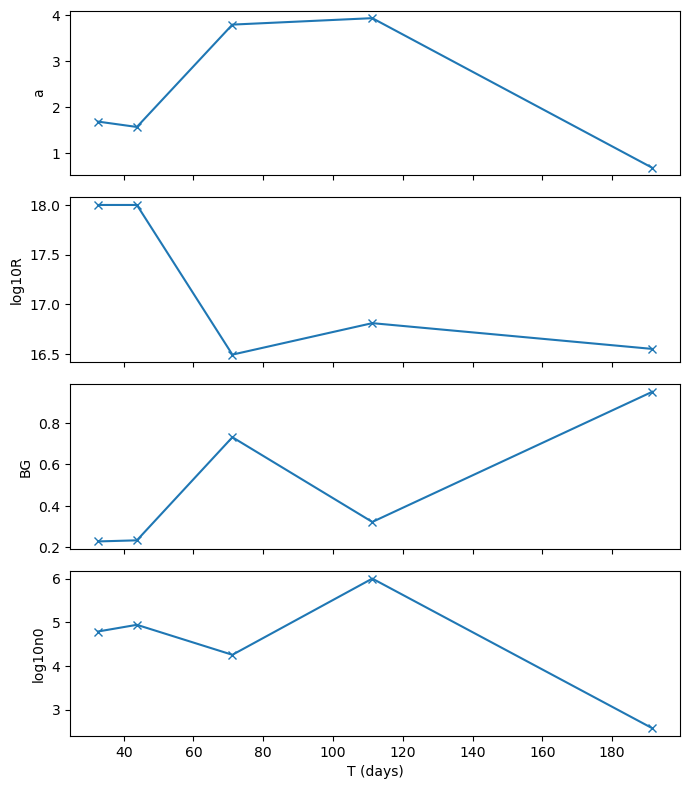

array([[ 1.68783722, 18.        ,  0.22837261,  4.7894201 ],
       [ 1.57077396, 18.        ,  0.23365779,  4.94256928],
       [ 3.799105  , 16.49604724,  0.7316454 ,  4.25642412],
       [ 3.93943728, 16.81231685,  0.32246058,  6.        ],
       [ 0.6815515 , 16.55342749,  0.95108544,  2.57636846]])

In [11]:
epochs = [1,2,3,4,5,6]

keeps4 = {}
for ep in epochs:
    keeps4[ep] = select_solutions(outs4[ep], delta_chi2=10.0)

plot_param_evolution_4(outs4, keeps4, epochs)
#plot_param_evolution(outs4, keeps4, epochs, show_err=True, min_keep=5)